# 01 — Anomaly Detection: Introduction

**Hour 2, 0–10 min: Load and explore the dataset**

We're picking up the story from the slides: a bank has thousands of transactions and no
labels telling us which ones are fraudulent. Before we train any model, we need to actually
**look at the data** — get a feel for what "normal" looks like, so that later we can judge
whether Isolation Forest's idea of "unusual" matches our own.

By the end of this notebook you will have:
- Loaded the transaction dataset
- Looked at its structure and basic statistics
- Visualized transaction amount, frequency, and timing
- Formed your own first impression of what looks unusual — **before** any algorithm tells you

## 1. Import libraries

Just the essentials — Pandas for tables, NumPy for numbers, Matplotlib for charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (9, 5)

## 2. Load the data

`bank_transaction_anomaly_dataset.csv` is a **synthetic** dataset built to feel like real bank
transactions. It does not represent any real bank or customer.

In [2]:
df = pd.read_csv("../data/bank_transaction_anomaly_dataset.csv")
df.shape

(5004, 8)

**What are we doing?** Loading the CSV into a Pandas DataFrame.
**What should we expect?** A table with one row per transaction and a handful of columns
describing that transaction.

In [3]:
df.head()

,transaction_id,customer_id,transaction_amount,transaction_frequency,transaction_hour,distance_from_usual_location_km,account_age_days,is_actual_anomaly
0,TXN500000,CUST20844,480000,1,8,0.4,1224,0
1,TXN500001,CUST20157,23354,1,11,1.2,759,0
2,TXN500002,CUST20872,63667,1,17,3.4,949,0
3,TXN500003,CUST20395,35539,1,11,2.1,2364,0
4,TXN500004,CUST20474,12527,1,19,0.1,3356,0


## 3. Understand the data

Each row is one transaction. Here's what each column means:

| Column | Meaning |
|---|---|
| `transaction_id` | Unique ID for the transaction |
| `customer_id` | Which customer made it |
| `transaction_amount` | Amount in ₦ |
| `transaction_frequency` | How many transactions this customer made in the same hour |
| `transaction_hour` | Hour of day (0–23) the transaction happened |
| `distance_from_usual_location_km` | Distance (km) from where this customer usually transacts |
| `account_age_days` | How long the account has existed |
| `is_actual_anomaly` | **Ground truth** — 1 if we (the dataset creators) planted this as an anomaly, 0 otherwise |

> **Important:** In a REAL fraud problem, `is_actual_anomaly` would not exist — that's the whole
> point of unsupervised learning. We've included it here ONLY so that later in this course we
> can check how well our model actually did. Today, pretend you can't see it until we get to
> the evaluation section.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5004 entries, 0 to 5003
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   transaction_id                   5004 non-null   object 
 1   customer_id                      5004 non-null   object 
 2   transaction_amount               5004 non-null   int64  
 3   transaction_frequency            5004 non-null   int64  
 4   transaction_hour                 5004 non-null   int64  
 5   distance_from_usual_location_km  5004 non-null   float64
 6   account_age_days                 5004 non-null   int64  
 7   is_actual_anomaly                5004 non-null   int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 312.9+ KB


## 4. Basic statistics

`describe()` gives us mean, std, min, max, and quartiles for every numeric column at a glance.

In [5]:
df.describe().round(1)

,transaction_amount,transaction_frequency,transaction_hour,distance_from_usual_location_km,account_age_days,is_actual_anomaly
count,5004.0,5004.0,5004.0,5004.0,5004.0,5004.0
mean,138760.1,1.7,13.7,6.3,1933.1,0.0
std,623095.1,2.5,4.2,27.1,1133.8,0.2
min,2575.0,1.0,0.0,0.0,33.0,0.0
25%,18440.5,1.0,11.0,1.0,910.0,0.0
50%,32627.5,1.0,14.0,2.5,1911.0,0.0
75%,68000.5,2.0,17.0,5.0,2873.0,0.0
max,8871391.0,33.0,24.0,397.4,3997.0,1.0


**What does this tell us?**
- `transaction_amount`: the mean is much higher than the median (50%) would suggest — a classic
  sign that a few very large values are pulling the average up. That's often what anomalies look
  like in raw statistics, even before we build any model.
- `transaction_frequency`: mostly small numbers (1-4), but the max is far higher — worth a closer look.

Let's also check: how many transactions are actually planted anomalies?

In [6]:
df["is_actual_anomaly"].value_counts()

is_actual_anomaly
0    4850
1     154
Name: count, dtype: int64

In [7]:
pct = df["is_actual_anomaly"].mean() * 100
print(f"{pct:.1f}% of transactions are actual anomalies")

3.1% of transactions are actual anomalies


## 5. Visualize transaction behaviour

### 5a. Transaction amount distribution

We'll use a log scale on the x-axis — transaction amounts span from a few thousand naira to
several million, and a normal (linear) scale would squash everything interesting into an
unreadable sliver.

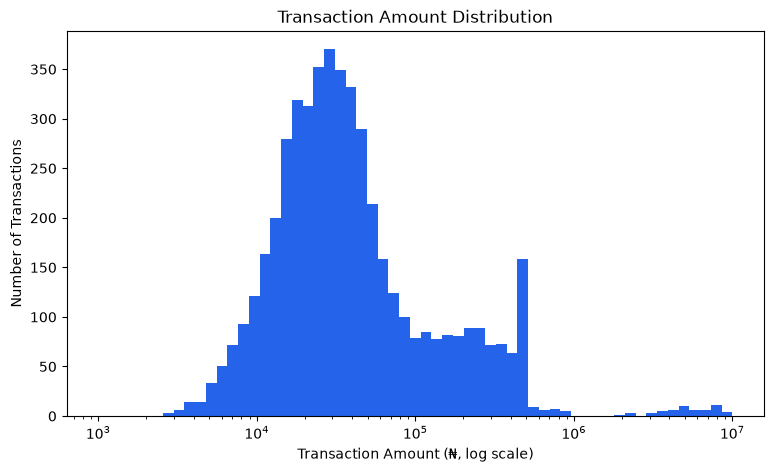

In [8]:
fig, ax = plt.subplots()
ax.hist(df["transaction_amount"], bins=np.logspace(np.log10(1000), np.log10(1e7), 60), color="#2563EB")
ax.set_xscale("log")
ax.set_xlabel("Transaction Amount (₦, log scale)")
ax.set_ylabel("Number of Transactions")
ax.set_title("Transaction Amount Distribution")
plt.show()

**What do we see?** A big cluster of "everyday" transaction amounts, and a thin scatter of
much larger ones off to the right. Those large ones are candidates for point anomalies — but
remember, an anomaly isn't only about being large (see the slides on contextual and collective
anomalies).

### 5b. Transaction frequency

How many transactions does a customer typically make within the same hour?

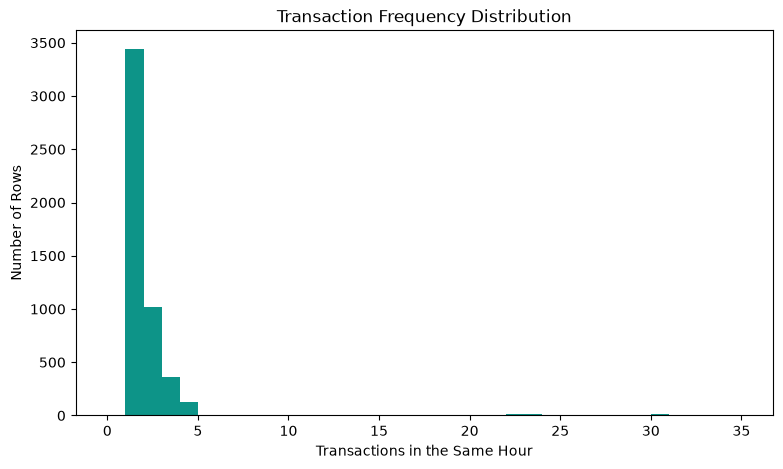

In [9]:
fig, ax = plt.subplots()
ax.hist(df["transaction_frequency"], bins=range(0, 36), color="#0D9488")
ax.set_xlabel("Transactions in the Same Hour")
ax.set_ylabel("Number of Rows")
ax.set_title("Transaction Frequency Distribution")
plt.show()

**What do we see?** Most rows show 1-4 transactions/hour. A small number show 15+ — that's
the signature of the "collective anomaly" pattern from the slides (a burst of rapid transactions).

### 5c. When do transactions happen?

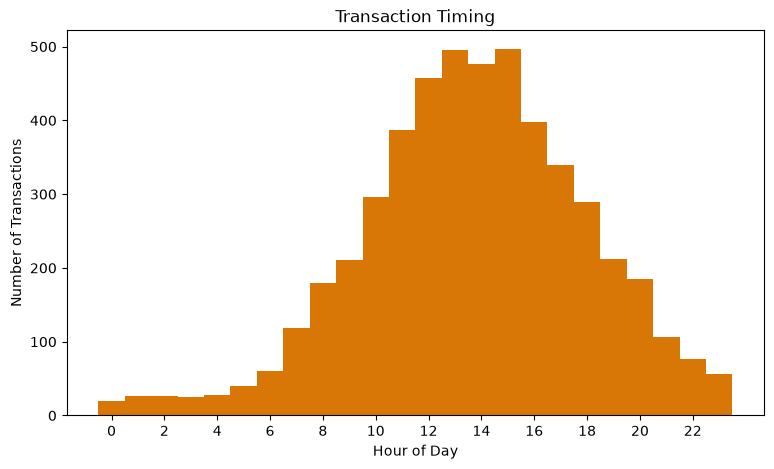

In [10]:
fig, ax = plt.subplots()
ax.hist(df["transaction_hour"], bins=range(0, 25), color="#D97706", align="left")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Transactions")
ax.set_title("Transaction Timing")
ax.set_xticks(range(0, 24, 2))
plt.show()

**What do we see?** Activity peaks during the day and drops off at night — matching normal
human behaviour. A cluster of transactions in the very early hours (1am-4am) stands out as
unusual, which connects back to the "contextual anomaly" idea from the slides.

### 5d. Amount vs. frequency — a first (unaided) look

Let's plot amount against frequency and colour by the ground-truth label, JUST to build
intuition about how these injected anomalies actually look in the data. Remember: in a real
project we would not have this colour information yet.

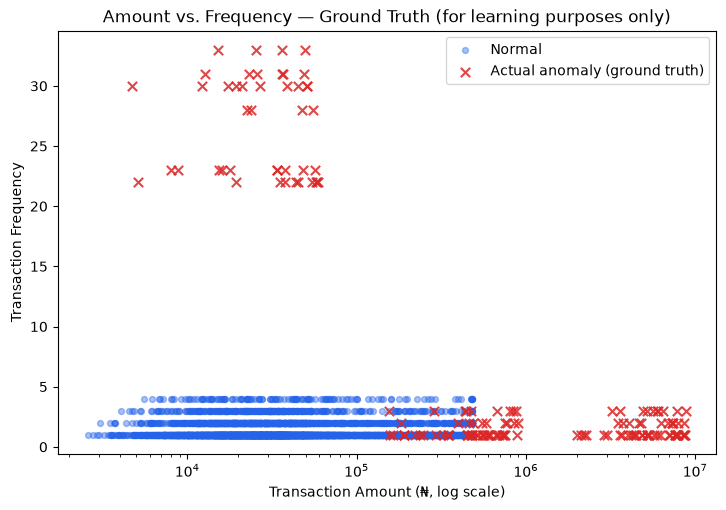

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
normal = df[df["is_actual_anomaly"] == 0]
anomaly = df[df["is_actual_anomaly"] == 1]
ax.scatter(normal["transaction_amount"], normal["transaction_frequency"],
           s=18, alpha=0.4, color="#2563EB", label="Normal")
ax.scatter(anomaly["transaction_amount"], anomaly["transaction_frequency"],
           s=45, alpha=0.85, color="#DC2626", marker="x", label="Actual anomaly (ground truth)")
ax.set_xscale("log")
ax.set_xlabel("Transaction Amount (₦, log scale)")
ax.set_ylabel("Transaction Frequency")
ax.legend()
ax.set_title("Amount vs. Frequency — Ground Truth (for learning purposes only)")
plt.show()

**Business perspective:** Notice the anomalies don't all sit in one obvious corner. Some are
just "big amount", some are just "high frequency", and some (the contextual ones — large
amount, very late at night, far from usual location) don't stand out on THIS chart at all. This
is exactly why we need an algorithm that considers **all the features together**, not just one
or two at a time — which is exactly what Isolation Forest does, coming up in the next notebook.

### Recap
- We loaded and explored a realistic (synthetic) transaction dataset.
- We saw that "unusual" shows up differently depending on which features you look at.
- We deliberately have NOT trained any model yet — that intuition-first step matters.

**Next: `02_Isolation_Forest.ipynb`** — where we actually train a model to find these patterns
automatically, without using the `is_actual_anomaly` column at all.